In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
mainPath = os.path.abspath(os.path.join(os.getcwd(), '..'))
if mainPath not in sys.path:
    sys.path.insert(0, mainPath)

# ETH_package

In [2]:
from building_physics import Zone
import supply_system
import emission_system
from radiation import Location
from radiation import Window
ElectricityOut = []
HeatingDemand  = []
HeatingEnergy  = []
CoolingDemand  = []
CoolingEnergy  = []
IndoorAir      = []
OutsideTemp    = []
SolarGains     = []
COP            = []

In [ ]:
GEOMETRY = {
    "WINDOW_AREA":  1501.3,
    "WALL_AREA"  :  5168.5,
    "FLOOR_AREA" :  9474.7,
    "VOLUME"     : 37738.8,
    "_alpha"     :     3.5, # coefficient for 'area of surfaces facing the room'
    "_beta"      :     0.4, # coefficient for 'south windows'
}

# WEATHER
epw_path      = "../../../epw/ED-TMYx.2023.epw"
EDI           = Location(epwfile_path=epw_path)
year          = 2023
latitude_deg  = 55.95
longitude_deg = -3.37

# O&M
t_m_prev         = 20
schedule_path    = os.path.join(mainPath, "auxiliary", "schedules_el_OFFICE.csv")
occupancyProfile = pd.read_csv(schedule_path)
gain_per_person  = 100
max_occupancy    = 765
appliance_gains  = 11.77

In [ ]:
Office  = Zone(
    window_area                        = GEOMETRY["WINDOW_AREA"],
    walls_area                         = GEOMETRY["WALL_AREA"],
    floor_area                         = GEOMETRY["FLOOR_AREA"],
    room_vol                           = GEOMETRY["VOLUME"],
    total_internal_area                = GEOMETRY["FLOOR_AREA"]*GEOMETRY["_alpha"],
    thermal_capacitance_per_floor_area = 165000,
    u_walls                            = 0.19,
    u_windows                          = 1.41,
    ach_vent                           = 1.21,
    ach_infl                           = 0.41,
    lighting_load                      = 4.25,
    t_set_heating                      = 21.0,
    t_set_cooling                      = 28.0,
    ventilation_efficiency             = 0.5,
    max_cooling_energy_per_floor_area  = -np.inf,
    max_heating_energy_per_floor_area  = np.inf,
    heating_supply_system              = supply_system.DirectHeater,
    cooling_supply_system              = supply_system.DirectCooler,
    heating_emission_system            = emission_system.AirConditioning,
    cooling_emission_system            = emission_system.AirConditioning,
)

SouthWindow  = Window(
    azimuth_tilt                      = 0,
    alititude_tilt                    = 90,
    glass_solar_transmittance         = 0.7,
    glass_light_transmittance         = 0.8,
    area                              = GEOMETRY["window"] * GEOMETRY["_beta"],
)

In [ ]:
for hour in range(8760):
    occupancy = occupancyProfile.loc[hour, "People"] * max_occupancy
    internal_gains = occupancy * gain_per_person + appliance_gains * Office.floor_area
    t_out = EDI.weather_data["drybulb_C"][hour]
    altitude, azimuth = EDI.calc_sun_position(
        latitude_deg=latitude_deg,longitude_deg=longitude_deg,
        year=year,
        hoy=hour
    )
    SouthWindow.calc_solar_gains(
        sun_altitude=altitude,sun_azimuth=azimuth,
        normal_direct_radiation=EDI.weather_data["dirnorrad_Whm2"][hour],
        horizontal_diffuse_radiation=EDI.weather_data["difhorrad_Whm2"][hour]
    )
    SouthWindow.calc_illuminance(
        sun_altitude=altitude,sun_azimuth=azimuth,
        normal_direct_illuminance=EDI.weather_data["dirnorillum_lux"][hour],
        horizontal_diffuse_illuminance=EDI.weather_data["difhorillum_lux"][hour]
    )
    Office.solve_energy(
        internal_gains=internal_gains,solar_gains=SouthWindow.solar_gains,t_out=t_out,t_m_prev=t_m_prev
    )
    Office.solve_lighting(
        illuminance=SouthWindow.transmitted_illuminance,occupancy=occupancy
    )
    t_m_prev = Office.t_m_next 
    HeatingDemand_kWh_m2 = (Office.heating_demand / 1000.0) /  GEOMETRY["FLOOR_AREA"]
    HeatingEnergy_kWh_m2 = (Office.heating_energy / 1000.0) /  GEOMETRY["FLOOR_AREA"]
    CoolingDemand_kWh_m2 = (Office.cooling_demand / 1000.0) /  GEOMETRY["FLOOR_AREA"]
    CoolingEnergy_kWh_m2 = (Office.cooling_energy / 1000.0) /  GEOMETRY["FLOOR_AREA"]
    ElectricityOut_kWh_m2 = (Office.electricity_out / 1000.0) /  GEOMETRY["FLOOR_AREA"]
    HeatingDemand.append(HeatingDemand_kWh_m2)
    HeatingEnergy.append(HeatingEnergy_kWh_m2)
    CoolingDemand.append(CoolingDemand_kWh_m2)
    CoolingEnergy.append(CoolingEnergy_kWh_m2)
    ElectricityOut.append(ElectricityOut_kWh_m2)
    IndoorAir.append(Office.t_air)
    OutsideTemp.append(t_out)
    SolarGains.append(SouthWindow.solar_gains)
    COP.append(Office.cop)

# Output

In [ ]:
annualResults = pd.DataFrame({
    "HeatingDemand" : HeatingDemand,
    "HeatingEnergy" : HeatingEnergy,
    "CoolingDemand" : CoolingDemand,
    "CoolingEnergy" : CoolingEnergy,
    "IndoorAir"     : IndoorAir,
    "OutsideTemp"   : OutsideTemp,
    "SolarGains"    : SolarGains,
    "COP"           : COP
})
annual_EUI = annualResults[["HeatingEnergy", "CoolingEnergy"]].sum()
annualResults.index = pd.date_range("2023-01-01", periods=8760, freq="h")
print(annual_EUI)
# monthly_EUI = (
#     annualResults[["HeatingEnergy", "CoolingEnergy"]]
#     .resample("ME")
#     .sum()
# )

HeatingEnergy    46.610272
CoolingEnergy     0.801241
dtype: float64


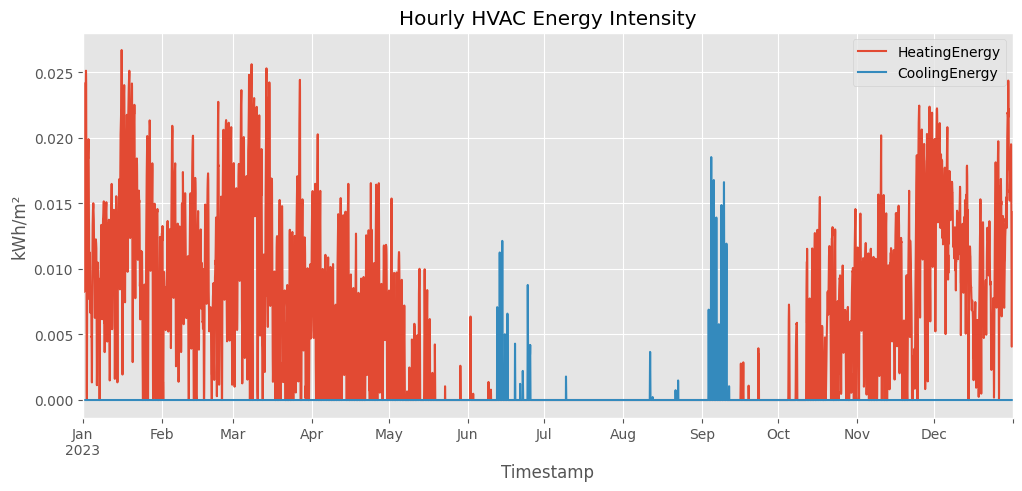

In [10]:
plt.style.use("ggplot")
ax = annualResults[["HeatingEnergy", "CoolingEnergy"]].plot(figsize=(12,5))
ax.minorticks_off()
plt.ylabel("kWh/m²")
plt.xlabel("Timestamp")
plt.title("Hourly HVAC Energy Intensity")
plt.show()

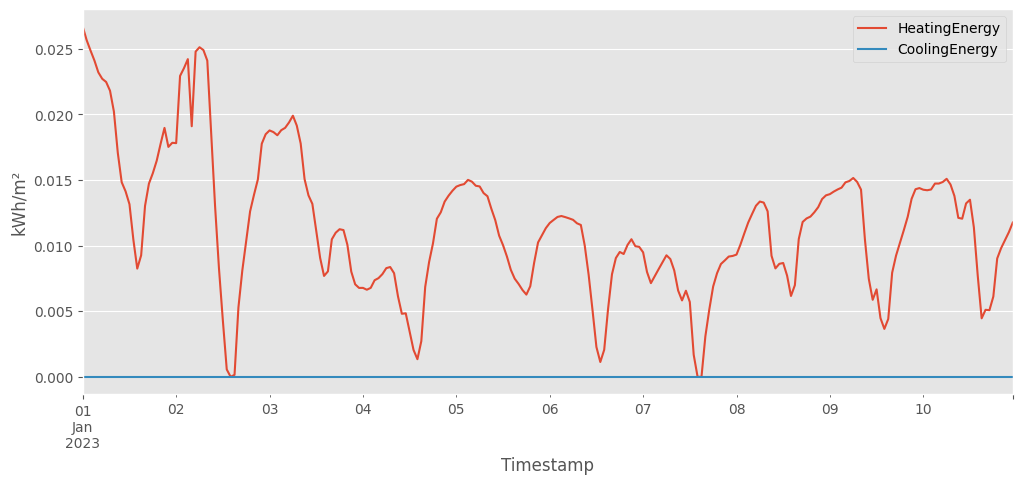

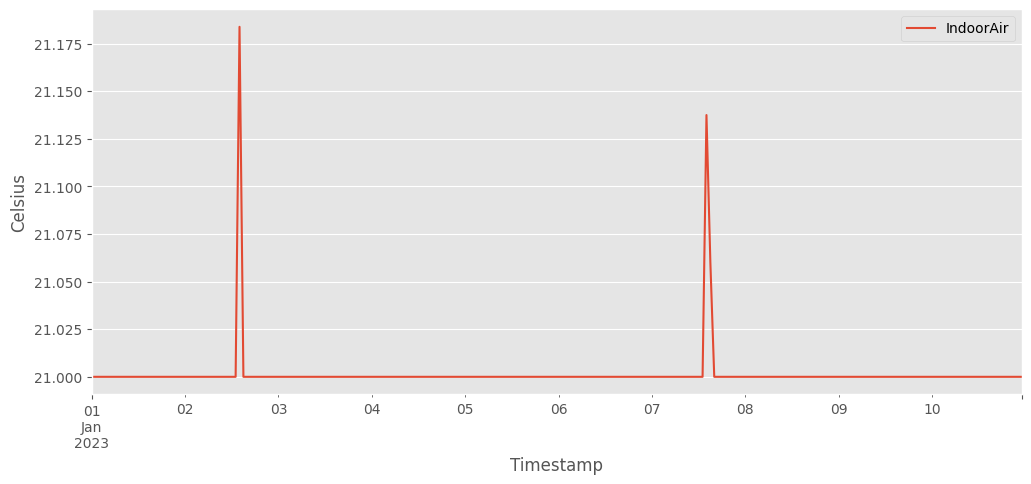

In [11]:
import matplotlib.pyplot as plt
import pandas as pd  # assuming annualResults is a pandas DataFrame

first_5_days = annualResults.iloc[:240]   # 5 days * 24 hours = 120 rows

plt.style.use("ggplot")
ax = first_5_days[["HeatingEnergy", "CoolingEnergy"]].plot(figsize=(12,5))
plt.ylabel("kWh/m²")
plt.xlabel("Timestamp")
plt.title("")
plt.show()

ax = first_5_days[["IndoorAir"]].plot(figsize=(12,5))
plt.ylabel("Celsius")
plt.xlabel("Timestamp")
plt.title("")
plt.show()